Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.1037 - mae: 0.6571 - val_loss: 0.4951 - val_mae: 0.4947
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4301 - mae: 0.4603 - val_loss: 0.4276 - val_mae: 0.4681
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3766 - mae: 0.4377 - val_loss: 0.4108 - val_mae: 0.4664
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3593 - mae: 0.4270 - val_loss: 0.3828 - val_mae: 0.4316
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3491 - mae: 0.4178 - val_loss: 0.3745 - val_mae: 0.4420
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3351 - mae: 0.4098 - val_loss: 0.3671 - val_mae: 0.4189
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3287 - mae: 0.4050 - val_loss: 0.3573 - val_mae: 0.4153
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3292 - mae: 0.3983 - val_loss: 0.3447 - val_mae: 0.4179
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3171 

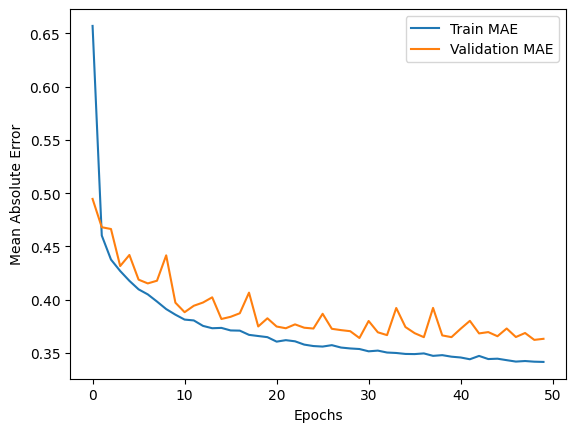

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, verbose=1)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Mean Absolute Error: {test_mae}")
predictions = model.predict(X_train[:5])
print("\nSample Predictions:", predictions.flatten())
print("Actual Values:", y_train[:5])
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()